In [1]:
import torch
import numpy as np

# if torch.backends.mps.is_available():
#     DEVICE = torch.device("mps")
# elif torch.cuda.is_available():
#     DEVICE = torch.device("cuda")
# else:
#     DEVICE = torch.device("cpu")
DEVICE = torch.device("cpu")

torch.manual_seed(42)
np.random.seed(42)
print("Device used:", DEVICE)

Device used: cpu


### Cube template

In [2]:
def get_unit_cube():
    """Returns (vertices [8,3], faces [12,3]) — unit cube centered at origin."""
    v = torch.tensor([
        [-0.5, -0.5, -0.5], [ 0.5, -0.5, -0.5],
        [ 0.5,  0.5, -0.5], [-0.5,  0.5, -0.5],
        [-0.5, -0.5,  0.5], [ 0.5, -0.5,  0.5],
        [ 0.5,  0.5,  0.5], [-0.5,  0.5,  0.5],
    ], dtype=torch.float32)
    f = torch.tensor([
        [0,1,2],[0,2,3],  # back
        [4,6,5],[4,7,6],  # front
        [0,4,5],[0,5,1],  # bottom
        [2,6,7],[2,7,3],  # top
        [0,7,4],[0,3,7],  # left
        [1,5,6],[1,6,2],  # right
    ], dtype=torch.long)
    return v, f


def loop_subdivide(vertices, faces):
    """One step of Loop subdivision — splits every triangle into 4."""
    V = vertices.shape[0]
    device = vertices.device
    edges_dict, mids = {}, []

    def midpoint(a, b):
        key = (min(a, b), max(a, b))
        if key not in edges_dict:
            edges_dict[key] = len(mids) + V
            mids.append((vertices[a] + vertices[b]) / 2.0)
        return edges_dict[key]

    new_faces = []
    for tri in faces.numpy():
        v0, v1, v2 = int(tri[0]), int(tri[1]), int(tri[2])
        m01, m12, m20 = midpoint(v0,v1), midpoint(v1,v2), midpoint(v2,v0)
        new_faces += [[v0,m01,m20],[v1,m12,m01],[v2,m20,m12],[m01,m12,m20]]

    new_v = torch.cat([vertices, torch.stack(mids).to(device)], 0) if mids else vertices
    new_f = torch.tensor(new_faces, dtype=torch.long, device=device)
    return new_v, new_f


def build_adjacency(vertices, faces):
    """Row-normalised dense adjacency [V,V] with self-loops."""
    V = vertices.shape[0]
    adj = torch.zeros(V, V)
    for tri in faces:
        for i in range(3):
            a, b = int(tri[i]), int(tri[(i+1)%3])
            adj[a, b] = adj[b, a] = 1.0
    adj += torch.eye(V)
    return adj / adj.sum(1, keepdim=True).clamp(min=1)


def build_laplacian(vertices, faces):
    """Uniform Laplacian L = I - D^{-1}A."""
    V = vertices.shape[0]
    adj = torch.zeros(V, V)
    for tri in faces:
        for i in range(3):
            a, b = int(tri[i]), int(tri[(i+1)%3])
            adj[a, b] = adj[b, a] = 1.0
    return torch.eye(V) - adj / adj.sum(1, keepdim=True).clamp(1)


# ── Test ─────────────────────────────────────────────────────────────────────
v0, f0 = get_unit_cube()
v1, f1 = loop_subdivide(v0, f0)
v2, f2 = loop_subdivide(v1, f1)
v3, f3 = loop_subdivide(v2, f2)
for label, v, f in [("Cube     ", v0, f0), ("Subdiv×1 ", v1, f1),("Subdiv×2 ", v2, f2), ("Subdiv×3 ", v3, f3)]:
    print(f"  {label}: {v.shape[0]:4d} verts, {f.shape[0]:4d} faces")

  Cube     :    8 verts,   12 faces
  Subdiv×1 :   26 verts,   48 faces
  Subdiv×2 :   98 verts,  192 faces
  Subdiv×3 :  386 verts,  768 faces


### Visualize subdivision progression

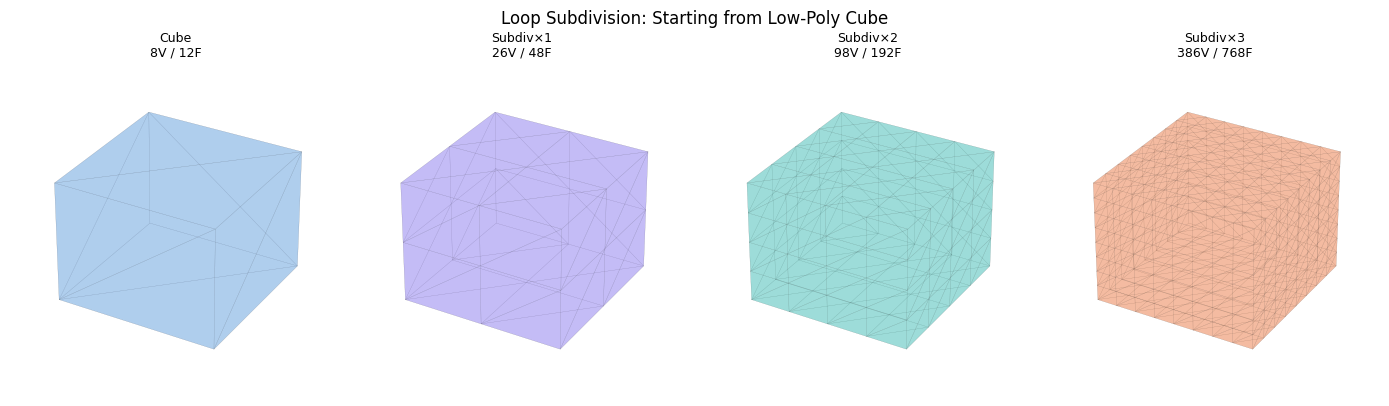

In [3]:
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_mesh(ax, verts, faces, title="", color="steelblue", alpha=0.25):
    v = verts.numpy()
    tris = [v[f] for f in faces.numpy()]
    poly = Poly3DCollection(tris, alpha=alpha, facecolor=color, edgecolor="#333", linewidth=0.15)
    ax.add_collection3d(poly)
    ax.set_xlim(-0.6, 0.6); ax.set_ylim(-0.6, 0.6); ax.set_zlim(-0.6, 0.6)
    ax.set_title(title, fontsize=9); ax.set_axis_off()

fig = plt.figure(figsize=(14, 4))
stages = [(v0,f0,"Cube\n8V / 12F"), (v1,f1,"Subdiv×1\n26V / 48F"), (v2,f2,"Subdiv×2\n98V / 192F"), (v3,f3,"Subdiv×3\n386V / 768F")]
colors = ["#4A90D9","#7B68EE","#20B2AA","#E8672A"]
for i,(vv,ff,title) in enumerate(stages):
    ax = fig.add_subplot(1,4,i+1,projection="3d")
    plot_mesh(ax, vv, ff, title, colors[i])
plt.suptitle("Loop Subdivision: Starting from Low-Poly Cube", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### Vertext projection & feature sampling

The bridge between 3D and 2D. For each 3D vertex:
1. Apply camera rotation + translation → camera-space coordinates
2. Perspective divide by Z → pixel coordinates
3. `grid_sample` bilinearly reads CNN features at that pixel location

This gives each vertex a **description of what the image looks like** at the position it"s currently occupying — which is exactly what the GCN needs to decide how to move it.

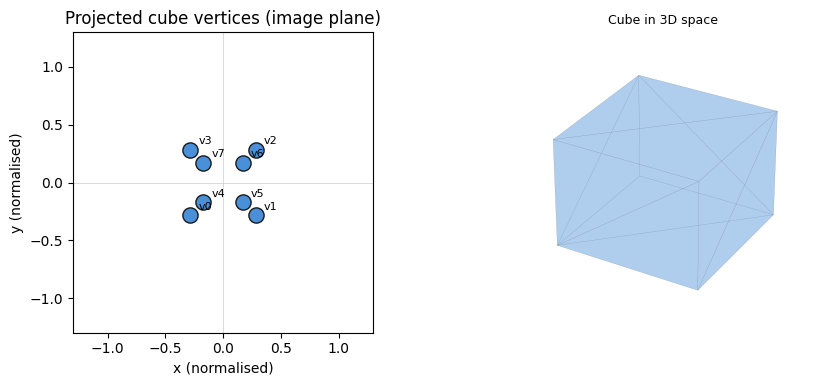

Coords range: min=-0.28  max=0.28


In [ ]:
import torch.nn.functional as F

def project_vertices(vertices, rot, trans, focal):
    """
    Pix3D camera model: v_cam = R @ v + T, then perspective divide.
    vertices : [B, V, 3]
    rot      : [B, 3, 3]
    trans    : [B, 3]
    focal    : [B]   normalised focal length (focal_px / (img_size/2))
    Returns  : [B, V, 2]  in [-1, 1]  (for grid_sample)
    """
    v_cam = torch.bmm(vertices, rot.transpose(1, 2)) + trans.unsqueeze(1)
    z = v_cam[..., 2:3].clamp(min=1e-6)
    f = focal.view(-1, 1, 1)
    xy = f * v_cam[..., :2] / z
    return xy.clamp(-1, 1)


def sample_features(feature_maps, coords):
    """
    Bilinearly sample feature maps at projected vertex coords.
    feature_maps : list of [B, C_i, H_i, W_i]
    coords       : [B, V, 2]
    Returns      : [B, V, sum_C_i]
    """
    grid = coords.unsqueeze(1)  # [B, 1, V, 2] for grid_sample
    sampled = []
    for fm in feature_maps:
        s = F.grid_sample(fm, grid, align_corners=True, mode="bilinear", padding_mode="border")  # [B,C,1,V]
        sampled.append(s.squeeze(2).permute(0, 2, 1))              # [B,V,C]
    return torch.cat(sampled, dim=-1)


# ── Visualise: project a cube onto image plane ─────────────────────────────
verts_b = v0.unsqueeze(0)                          # [1, 8, 3]
rot_id = torch.eye(3).unsqueeze(0)                # identity rotation
trans_z = torch.tensor([[0., 0., 2.]])             # 2 units in front of camera
focal = torch.tensor([0.85])

coords_2d = project_vertices(verts_b, rot_id, trans_z, focal)
pts = coords_2d.squeeze(0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 2D projection view
axes[0].scatter(pts[:,0], pts[:,1], s=120, c="#4A90D9", zorder=3, edgecolors="#1a1a1a")
for i,(x,y) in enumerate(pts):
    axes[0].annotate(f"v{i}", (x,y), xytext=(6,4), textcoords="offset points", fontsize=8)
axes[0].set_xlim(-1.3,1.3)
axes[0].set_ylim(-1.3,1.3)
axes[0].axhline(0,color="#ccc",lw=0.5)
axes[0].axvline(0,color="#ccc",lw=0.5)
axes[0].set_aspect("equal")
axes[0].set_title("Projected cube vertices (image plane)")
axes[0].set_xlabel("x (normalised)")
axes[0].set_ylabel("y (normalised)")

# 3D view of same cube
ax3d = fig.add_subplot(1, 2, 2, projection="3d", position=[0.52, 0.1, 0.45, 0.8])
plot_mesh(ax3d, v0, f0, "Cube in 3D space", "#4A90D9")
axes[1].remove()

plt.tight_layout()
plt.show()
print("Coords range: min={:.2f}  max={:.2f}".format(pts.min(), pts.max()))

### Encoder

We freeze the lower 2 stages (stem, layer1) and fine-tune the upper stages. This keeps low-level edge/texture features intact while letting the network learn furniture-specific patterns on top.

| Stage | Channels | Spatial size (224px input) | Captures |
|---|---|---|---|
| 1 | 256 | 56×56 | Edges, textures |
| 2 | 512 | 28×28 | Parts, corners |
| 3 | 1024 | 14×14 | Object structure |
| 4 | 2048 | 7×7 | Semantic shape |

In [5]:
from torch import nn
from torchvision.models import resnet50, ResNet50_Weights, efficientnet_b4, EfficientNet_B4_Weights

class ResNetEncoder(nn.Module):
    def __init__(self, pretrained=True, freeze_stages=2):
        super().__init__()
        weights = ResNet50_Weights.DEFAULT if pretrained else None
        bb = resnet50(weights=weights)
        self.stem = nn.Sequential(bb.conv1, bb.bn1, bb.relu, bb.maxpool)
        self.layer1 = bb.layer1  # [B, 256, H/4,  W/4]
        self.layer2 = bb.layer2  # [B, 512, H/8,  W/8]
        self.layer3 = bb.layer3  # [B,1024, H/16, W/16]
        self.layer4 = bb.layer4  # [B,2048, H/32, W/32]
        self.feat_dims = [256, 512, 1024, 2048]
        for stage in [self.stem, self.layer1, self.layer2][:freeze_stages]:
            for p in stage.parameters(): 
                p.requires_grad = False

    def forward(self, x):
        x = self.stem(x)
        f1 = self.layer1(x)
        f2 = self.layer2(f1)
        f3 = self.layer3(f2)
        f4 = self.layer4(f3)
        return [f1, f2, f3, f4]
    

class EfficientNetEncoder(nn.Module):
    def __init__(self, pretrained=True, freeze_stages=2):
        super().__init__()
        weights = EfficientNet_B4_Weights.DEFAULT if pretrained else None
        bb = efficientnet_b4(weights=weights)
        self.stem = nn.Sequential(bb.features[0])
        self.block1 = nn.Sequential(*bb.features[1:3])
        self.block2 = nn.Sequential(*bb.features[3:5])
        self.block3 = nn.Sequential(*bb.features[5:7])
        self.block4 = nn.Sequential(*bb.features[7:])
        
        # Compute actual feature dimensions by running a forward pass
        with torch.no_grad():
            dummy = torch.randn(1, 3, 224, 224)
            x = self.stem(dummy)
            f1 = self.block1(x)
            f2 = self.block2(f1)
            f3 = self.block3(f2)
            f4 = self.block4(f3)
            self.feat_dims = [f.shape[1] for f in [f1, f2, f3, f4]]
        
        for stage in [self.stem, self.block1, self.block2][:freeze_stages]:
            for p in stage.parameters():
                p.requires_grad = False

    def forward(self, x):
        x = self.stem(x)
        f1 = self.block1(x)
        f2 = self.block2(f1)
        f3 = self.block3(f2)
        f4 = self.block4(f3)
        return [f1, f2, f3, f4]


encoder = ResNetEncoder(pretrained=True, freeze_stages=2).to(DEVICE).eval()

dummy = torch.randn(1, 3, 224, 224, device=DEVICE)
with torch.no_grad():
    feat_maps = encoder(dummy)

print("Feature pyramid:")
for i, fm in enumerate(feat_maps):
    print(f"  Stage {i+1}: {tuple(fm.shape)}")

n_frozen = sum(p.numel() for p in encoder.parameters() if not p.requires_grad)
n_train = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
print(f"Frozen params: {n_frozen:,}  |  Trainable params: {n_train:,}")
print(f"Feature dims sum: {sum(encoder.feat_dims):,}")

Feature pyramid:
  Stage 1: (1, 256, 56, 56)
  Stage 2: (1, 512, 28, 28)
  Stage 3: (1, 1024, 14, 14)
  Stage 4: (1, 2048, 7, 7)
Frozen params: 225,344  |  Trainable params: 23,282,688
Feature dims sum: 3,840


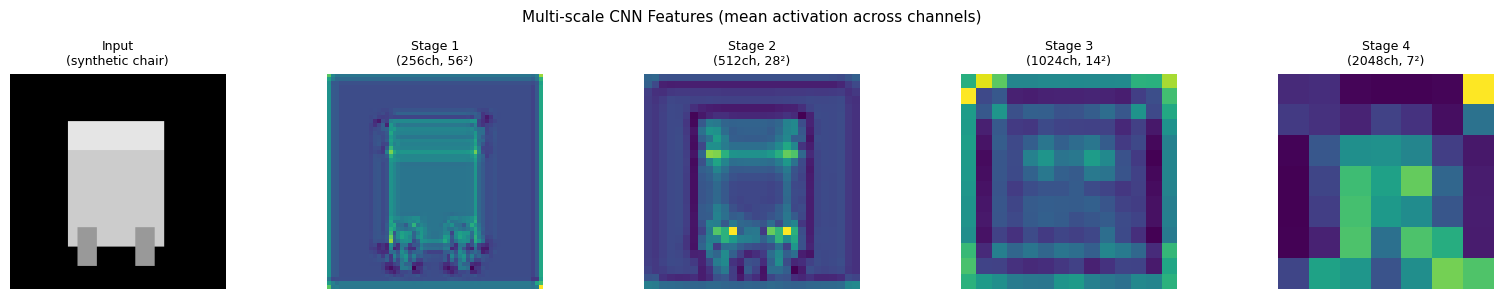

In [6]:
# Create a synthetic furniture-like test image
test_img = torch.zeros(1, 3, 224, 224)
test_img[0, :, 50:180, 60:160] = 0.8   # main body
test_img[0, :, 160:200, 70:90]  = 0.6  # left leg
test_img[0, :, 160:200, 130:150] = 0.6 # right leg
test_img[0, :, 50:80,   60:160]  = 0.9 # backrest

with torch.no_grad():
    feats_vis = encoder(test_img.to(DEVICE))

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
axes[0].imshow(test_img[0].permute(1,2,0).clamp(0,1))
axes[0].set_title("Input\n(synthetic chair)", fontsize=9); axes[0].axis("off")

names = ["Stage 1\n(256ch, 56²)", "Stage 2\n(512ch, 28²)",
         "Stage 3\n(1024ch, 14²)", "Stage 4\n(2048ch, 7²)"]
for ax, fm, name in zip(axes[1:], feats_vis, names):
    ax.imshow(fm[0].mean(0).cpu(), cmap="viridis")
    ax.set_title(name, fontsize=9); ax.axis("off")

plt.suptitle("Multi-scale CNN Features (mean activation across channels)", fontsize=11)
plt.tight_layout(); plt.show()

### GCN

The GCN is the heart of the deformation.

**GraphConv:** `h_new = ReLU( W_self·h + W_neigh·(A·h) + b )`

- `A·h` aggregates features from neighbouring vertices
- The network learns to combine *own* features and *neighbour* context
- A **residual skip** prevents vanishing gradients across stages
- A small **displacement head** predicts `Δv ∈ ℝ³` per vertex
- Final positions: `v_new = v_old + Δv` (residual updates, easier to optimise)

In [7]:
class GraphConv(nn.Module):
    """Single graph convolution layer with neighbour aggregation."""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.fc_self = nn.Linear(in_dim, out_dim, bias=False)
        self.fc_neigh = nn.Linear(in_dim, out_dim, bias=False)
        self.bn = nn.BatchNorm1d(out_dim)
        self.bias = nn.Parameter(torch.zeros(out_dim))

    def forward(self, x, adj):
        # x: [B,V,F]   adj: [V,V] pre-normalised
        B, V, _ = x.shape
        neigh = torch.einsum("vw,bwf->bvf", adj, x)  # aggregate neighbours
        out = self.fc_self(x) + self.fc_neigh(neigh) + self.bias
        out = self.bn(out.reshape(B*V, -1)).reshape(B, V, -1)
        return F.relu(out)


class GCNBlock(nn.Module):
    """Two GraphConv layers with residual skip."""
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.gc1 = GraphConv(in_dim, hidden_dim)
        self.gc2 = GraphConv(hidden_dim, hidden_dim)
        self.skip = nn.Linear(in_dim, hidden_dim, bias=False) if in_dim != hidden_dim else nn.Identity()

    def forward(self, x, adj):
        return self.gc2(self.gc1(x, adj), adj) + self.skip(x)


class DeformStage(nn.Module):
    """N GCNBlocks → displacement head → v_new = v_old + Δv"""
    def __init__(self, feat_dim, hidden_dim=128, n_blocks=2):
        super().__init__()
        self.blocks = nn.ModuleList([
            GCNBlock(feat_dim if i==0 else hidden_dim, hidden_dim)
            for i in range(n_blocks)
        ])
        self.disp_head = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ReLU(), nn.Linear(64, 3)
        )

    def forward(self, feats, verts, adj):
        h = feats
        for blk in self.blocks: h = blk(h, adj)
        new_verts = verts + self.disp_head(h)  # residual update
        return new_verts, h


# ── Test GCN forward ─────────────────────────────────────────────────────────
B, FC, H = 2, 64, 128
V = v1.shape[0]  # 26 verts after 1 subdivision
adj_test = build_adjacency(v1, f1)

stage_test = DeformStage(feat_dim=FC, hidden_dim=H, n_blocks=2)
dummy_feats = torch.randn(B, V, FC)
dummy_verts = torch.randn(B, V, 3)

new_v, h_out = stage_test(dummy_feats, dummy_verts, adj_test)
delta = (new_v - dummy_verts).abs()
print(f"Input  verts: {tuple(dummy_verts.shape)}")
print(f"Output verts: {tuple(new_v.shape)}")
print(f"Hidden feats: {tuple(h_out.shape)}")
print(f"Mean |Δv|   : {delta.mean().item():.4f}  Max: {delta.max().item():.4f}")

Input  verts: (2, 26, 3)
Output verts: (2, 26, 3)
Hidden feats: (2, 26, 128)
Mean |Δv|   : 0.3538  Max: 1.1026


In [8]:
class Furniture3D(nn.Module):
    def __init__(self, encoder, hidden_dim=128, n_stages=3, n_gcn_blocks=2):
        super().__init__()
        self.n_stages = n_stages
        self.hidden_dim = hidden_dim

        # Pretrained ResNet-50 encoder
        self.encoder = encoder
        total_img = sum(self.encoder.feat_dims)  # 3840

        # Per-stage: projector MLP + deformation GCN
        self.projectors = nn.ModuleList()
        self.deform_stages = nn.ModuleList()
        for i in range(n_stages):
            # Stage 0: img(3840) + xyz(3) | Stage 1+: img + prev_hidden + xyz
            in_dim = (total_img + 3) if i == 0 else (total_img + hidden_dim + 3)
            self.projectors.append(nn.Sequential(
                nn.Linear(in_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
            ))
            self.deform_stages.append(DeformStage(hidden_dim, hidden_dim, n_gcn_blocks))

        # Pre-compute fixed mesh topology for each stage
        self._build_templates(n_stages)

    def _build_templates(self, n_stages):
        verts, faces = get_unit_cube()
        self.templates = []
        for i in range(n_stages):
            adj = build_adjacency(verts, faces)
            lap = build_laplacian(verts, faces)
            self.register_buffer(f"adj_{i}", adj)
            self.register_buffer(f"lap_{i}", lap)
            self.templates.append((verts.clone(), faces.clone()))
            if i < n_stages - 1:
                verts, faces = loop_subdivide(verts, faces)

    def forward(self, image, rot, trans, focal):
        B, device = image.shape[0], image.device

        feat_maps = self.encoder(image)  # multi-scale features
        all_verts, all_faces, all_laps = [], [], []
        prev_h = None

        for i in range(self.n_stages):
            adj = getattr(self, f"adj_{i}").to(device)
            lap = getattr(self, f"lap_{i}").to(device)
            verts_tmpl, faces = self.templates[i]
            verts = verts_tmpl.to(device).unsqueeze(0).expand(B,-1,-1).clone()
            V = verts.shape[1]

            # Project + sample image features at vertex locations
            coords = project_vertices(verts, rot, trans, focal)   # [B,V,2]
            img_feat = sample_features(feat_maps, coords)            # [B,V,3840]

            # Build input for projector MLP
            if prev_h is None:
                combined = torch.cat([img_feat, verts], dim=-1)
            else:
                if prev_h.shape[1] != V:  # interpolate if vertex count changed
                    prev_h = F.interpolate(
                        prev_h.permute(0,2,1), size=V, mode="linear", align_corners=False
                    ).permute(0,2,1)
                combined = torch.cat([img_feat, prev_h, verts], dim=-1)

            vertex_feats = self.projectors[i](combined)              # [B,V,hidden]
            new_verts, hidden = self.deform_stages[i](vertex_feats, verts, adj)

            all_verts.append(new_verts)
            all_faces.append(faces)
            all_laps.append(lap)
            prev_h = hidden

        return {"vertices": all_verts, "faces": all_faces, "laplacians": all_laps}


# ── Build and inspect ────────────────────────────────────────────────────────
freeze_stages = 2
model = Furniture3D(encoder=encoder, hidden_dim=128, n_stages=3, n_gcn_blocks=2).to(DEVICE)

total_p = sum(p.numel() for p in model.parameters())
train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_p:>12,}")
print(f"Trainable       : {train_p:>12,}")
print(f"Frozen (encoder): {total_p - train_p:>12,}")

Total params    :   25,491,145
Trainable       :   25,265,801
Frozen (encoder):      225,344


In [9]:
B = 2
img_test = torch.randn(B, 3, 224, 224, device=DEVICE)
rot_test = torch.eye(3, device=DEVICE).unsqueeze(0).expand(B,-1,-1).clone()
trans_test = torch.zeros(B, 3, device=DEVICE); trans_test[:, 2] = 2.0
focal_test = torch.ones(B, device=DEVICE) * 0.85

model.eval()
with torch.no_grad():
    out = model(img_test, rot_test, trans_test, focal_test)

print("Forward pass output:")
for i, v in enumerate(out["vertices"]):
    f = out["faces"][i]
    print(f"  Stage {i+1}: verts {tuple(v.shape)}  faces {tuple(f.shape)}")

Forward pass output:
  Stage 1: verts (2, 8, 3)  faces (12, 3)
  Stage 2: verts (2, 26, 3)  faces (48, 3)
  Stage 3: verts (2, 98, 3)  faces (192, 3)


### Loss Functions

| Loss | Formula | Role |
|---|---|---|
| **Chamfer Distance** | Σ min‖p_i − q_j‖² (bidirectional) | Main shape accuracy |
| **Edge Length** | mean(edge lengths) | Prevents degenerate triangles |
| **Laplacian** | ‖L·V‖² | Prevents self-intersections / keeps surface smooth |

We apply these at **every stage**, with coarse stages getting less weight (0.2 / 0.3 / 0.5). This is the coarse-to-fine curriculum.

In [ ]:
def chamfer_distance(pred, gt):
    """Bidirectional Chamfer. pred,gt: [B,N,3]"""
    d = ((pred.unsqueeze(2) - gt.unsqueeze(1))**2).sum(-1)  # [B,N,M]
    return d.min(2).values.mean() + d.min(1).values.mean()


def edge_loss(vertices, faces):
    """Mean edge length — keeps tessellation uniform."""
    v0, v1, v2 = vertices[:,faces[:,0]], vertices[:,faces[:,1]], vertices[:,faces[:,2]]
    return torch.stack([
        (v0-v1).norm(dim=-1), (v1-v2).norm(dim=-1), (v2-v0).norm(dim=-1)
    ]).mean()


def laplacian_loss(vertices, lap):
    """Smoothing loss: ||L @ V||^2"""
    return (torch.einsum("vw,bwc->bvc", lap, vertices)**2).mean()


def compute_loss(pred_verts, gt_pts, faces, lap, w_cd=1.0, w_edge=0.1, w_lap=0.5):
    cd  = chamfer_distance(pred_verts, gt_pts)
    el  = edge_loss(pred_verts, faces)
    lpl = laplacian_loss(pred_verts, lap)
    total = w_cd*cd + w_edge*el + w_lap*lpl
    return total, {"chamfer": cd.item(), "edge": el.item(), "laplacian": lpl.item()}


# ── Test losses ───────────────────────────────────────────────────────────────
pred_v = out["vertices"][2]           # stage 3 output [2, 98, 3]
gt_pts = torch.randn(2, 2048, 3, device=DEVICE) * 0.4
faces_s3 = out["faces"][2].to(DEVICE)
lap_s3   = out["laplacians"][2].to(DEVICE)

loss_val, breakdown = compute_loss(pred_v, gt_pts, faces_s3, lap_s3)
print(f"Total : {loss_val.item():.4f}")
for k,v in breakdown.items(): print(f"  {k:12s}: {v:.4f}")

Total : 0.1206
  chamfer     : 0.0867
  edge        : 0.3062
  laplacian   : 0.0067


In [ ]:
import os
import json
import random
from PIL import Image
from torchvision import transforms

PIX3D_CATS = ["bed","bookcase","chair","desk","misc","sofa","table","tool","wardrobe"]
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def load_obj(path):
    """Minimal OBJ loader → (verts [V,3], faces [F,3])."""
    verts, faces = [], []
    with open(path) as fh:
        for line in fh:
            p = line.strip().split()
            if not p: continue
            if p[0] == "v": verts.append([float(x) for x in p[1:4]])
            elif p[0] == "f":
                idx = [int(x.split("/")[0])-1 for x in p[1:]]
                for i in range(1, len(idx)-1):
                    faces.append([idx[0], idx[i], idx[i+1]])
    return torch.tensor(verts, dtype=torch.float32), torch.tensor(faces, dtype=torch.long)


def normalise_mesh(v):
    """Centre and scale to unit sphere."""
    v = v - (v.max(0).values + v.min(0).values) / 2
    return v / v.norm(dim=-1).max().clamp(1e-8)


def sample_surface(verts, faces, n=2048):
    """Sample n points uniformly on triangle surfaces."""
    v0,v1,v2 = verts[faces[:,0]], verts[faces[:,1]], verts[faces[:,2]]
    areas = 0.5 * torch.cross(v1-v0, v2-v0, dim=-1).norm(dim=-1)
    prob = (areas / areas.sum().clamp(1e-8)).numpy()
    fi = torch.from_numpy(np.random.choice(len(faces), n, p=prob))
    r1 = torch.rand(n).sqrt()
    u, v, w = 1-r1, r1*(1-torch.rand(n)), r1*torch.rand(n)
    return (u[:,None]*verts[faces[fi,0]]
          + v[:,None]*verts[faces[fi,1]]
          + w[:,None]*verts[faces[fi,2]])


class Pix3DDataset(torch.utils.data.Dataset):
    def __init__(self, root, split="train", categories=None, img_size=224, n_pts=2048):
        self.root = root
        self.n_pts = n_pts
        with open(os.path.join(root, "pix3d.json")) as f:
            anns = json.load(f)

        cats = set(categories or PIX3D_CATS)
        anns = [a for a in anns if a["category"] in cats and not a.get("truncated") and not a.get("occluded")]
        random.seed(42)
        random.shuffle(anns)
        n = len(anns)
        splits = {"train": anns[:int(0.8*n)], "val": anns[int(0.8*n):int(0.9*n)], "test": anns[int(0.9*n):]}
        self.samples = splits[split]
        self.tfm = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

    def __len__(self): 
        return len(self.samples)

    def __getitem__(self, idx):
        a = self.samples[idx]
        image = self.tfm(Image.open(os.path.join(self.root, a["img"])).convert("RGB"))
        verts, faces = load_obj(os.path.join(self.root, a["model"]))
        verts = normalise_mesh(verts)
        gt_pts = sample_surface(verts, faces, self.n_pts)
        rot = torch.tensor(a["rot_mat"],  dtype=torch.float32)  # [3,3]
        trans = torch.tensor(a["trans_mat"],dtype=torch.float32)  # [3]
        w, h = a["img_size"]
        focal = torch.tensor(a["focal_length"] / (max(w,h)/2.), dtype=torch.float32)
        return {"image": image, "gt_points": gt_pts, "rot": rot, "trans": trans, "focal": focal}


print("Dataset class defined.")

# Usage:
PIX3D_ROOT = "../data/pix3d"
ds = Pix3DDataset(PIX3D_ROOT, "train", categories=["chair"])
print(f"{len(ds)} training samples")
sample = ds[0]
print({k: tuple(v.shape) if hasattr(v,"shape") else v for k,v in sample.items()})

Dataset class defined.
2451 training samples
{'image': (3, 224, 224), 'gt_points': (2048, 3), 'rot': (3, 3), 'trans': (3,), 'focal': ()}


### Training Loop

Key design choices:
- **Differential LR:** encoder gets 10× lower LR (it"s already pretrained)
- **Gradient clipping:** stabilises GCN training
- **Coarse-to-fine weights:** [0.2, 0.3, 0.5] — final stage matters most

In [12]:
import time
from tqdm.auto import tqdm
from IPython.display import display, clear_output
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

STAGE_WEIGHTS = [0.2, 0.3, 0.5]  # coarse → fine supervision

def _render_step(fig, axes, step_losses, val_losses, epoch, n_epochs,
                 pred_verts_list, faces_list, gt_pts, device):
    """Redraw loss curves + mesh deformation in-place."""
    for ax in axes:
        ax.cla()

    # ── Loss curve ────────────────────────────────────────────────────────────
    ax_loss = axes[0]
    ax_loss.plot(step_losses, color='#4A90D9', linewidth=1.2, label='train (step)')
    if val_losses:
        x_val = [int(i * len(step_losses) / len(val_losses)) for i in range(len(val_losses))]
        ax_loss.plot(x_val, val_losses, 'o--', color='#E8672A',
                     linewidth=1.2, markersize=4, label='val (epoch)')
    ax_loss.set_title(f'Loss  (epoch {epoch}/{n_epochs})', fontsize=9)
    ax_loss.set_xlabel('step', fontsize=8)
    ax_loss.set_ylabel('loss', fontsize=8)
    ax_loss.legend(fontsize=8)
    ax_loss.tick_params(labelsize=7)
    ax_loss.grid(True, linewidth=0.4, alpha=0.5)

    # ── Mesh stages ───────────────────────────────────────────────────────────
    stage_colors = ['#4A90D9', '#7B68EE', '#E8672A']
    if gt_pts is not None:
        gp = gt_pts[0].detach().cpu().numpy()
        axes[1].scatter(*gp.T, s=1, c='#20B2AA', alpha=0.4)
        axes[1].set_title('GT Point Cloud', fontsize=9)
        axes[1].set_axis_off()

    for i, (verts, faces) in enumerate(zip(pred_verts_list, faces_list)):
        ax = axes[2 + i]
        pv = verts[0].detach().cpu().numpy()
        ff = faces.cpu().numpy()
        tris = [pv[f] for f in ff]
        poly = Poly3DCollection(tris, alpha=0.3, facecolor=stage_colors[i],
                                edgecolor='#555', linewidth=0.1)
        ax.add_collection3d(poly)
        lim = 0.6
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
        ax.set_title(f'Stage {i+1}  {pv.shape[0]}V', fontsize=9)
        ax.set_axis_off()

    fig.suptitle(f'Training progress — epoch {epoch}/{n_epochs}', fontsize=11)
    fig.tight_layout()
    clear_output(wait=True)
    display(fig)


def train(model, loader, optimizer, n_epochs=5, val_loader=None, vis_every=20, device=DEVICE):
    history = {'train': [], 'val': []}
    step_losses, val_losses = [], []

    n_stages = model.n_stages
    # 1 loss + 1 GT cloud + n_stages meshes
    n_cols = 1 + 1 + n_stages
    fig = plt.figure(figsize=(4 * n_cols, 4))
    axes_flat = []
    axes_flat.append(fig.add_subplot(1, n_cols, 1))
    axes_flat.append(fig.add_subplot(1, n_cols, 2, projection='3d'))
    for k in range(n_stages):
        axes_flat.append(fig.add_subplot(1, n_cols, 3 + k, projection='3d'))
    plt.close(fig)  # don't auto-display yet

    last_out, last_gt = None, None
    global_step = 0

    epoch_bar = tqdm(range(1, n_epochs + 1), desc='Epochs', unit='epoch')
    for epoch in epoch_bar:
        model.train()
        epoch_loss, t0 = 0.0, time.time()

        step_bar = tqdm(loader, desc=f'Train {epoch}/{n_epochs}', leave=False, unit='batch')
        for batch in step_bar:
            img = batch['image'].to(device)
            gt = batch['gt_points'].to(device)
            rot = batch['rot'].to(device)
            trans = batch['trans'].to(device)
            focal = batch['focal'].to(device)

            optimizer.zero_grad()
            out = model(img, rot, trans, focal)

            loss = torch.tensor(0., device=device)
            for verts, faces, lap, w in zip(
                out['vertices'], out['faces'], out['laplacians'], STAGE_WEIGHTS
            ):
                l, _ = compute_loss(verts, gt, faces.to(device), lap.to(device))
                loss = loss + w * l

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            epoch_loss += loss.item()
            step_losses.append(loss.item())
            last_out, last_gt = out, gt
            global_step += 1

            step_bar.set_postfix(loss=f'{loss.item():.4f}')

            if global_step % vis_every == 0:
                _render_step(fig, axes_flat, step_losses, val_losses,
                             epoch, n_epochs,
                             last_out['vertices'], last_out['faces'],
                             last_gt, device)

        train_avg = epoch_loss / len(loader)
        history['train'].append(train_avg)

        val_avg = None
        if val_loader:
            model.eval()
            v_loss = 0.0
            val_bar = tqdm(val_loader, desc=f'Val   {epoch}/{n_epochs}',
                           leave=False, unit='batch')
            with torch.no_grad():
                for batch in val_bar:
                    img = batch['image'].to(device)
                    gt = batch['gt_points'].to(device)
                    rot = batch['rot'].to(device)
                    trans = batch['trans'].to(device)
                    focal = batch['focal'].to(device)
                    out = model(img, rot, trans, focal)
                    for verts, faces, lap, w in zip(
                        out['vertices'], out['faces'], out['laplacians'], STAGE_WEIGHTS
                    ):
                        l, _ = compute_loss(verts, gt, faces.to(device), lap.to(device))
                        v_loss += w * l.item()
                    val_bar.set_postfix(loss=f'{v_loss / (val_bar.n or 1):.4f}')
            val_avg = v_loss / len(val_loader)
            history['val'].append(val_avg)
            val_losses.append(val_avg)

        # Always render at end of epoch
        if last_out is not None:
            _render_step(fig, axes_flat, step_losses, val_losses,
                         epoch, n_epochs,
                         last_out['vertices'], last_out['faces'],
                         last_gt, device)

        t = time.time() - t0
        postfix = {'train': f'{train_avg:.4f}', 'time': f'{t:.1f}s'}
        if val_avg is not None:
            postfix['val'] = f'{val_avg:.4f}'
        epoch_bar.set_postfix(**postfix)

    plt.close(fig)
    return history


print("--- Smoke test (3 steps with random data) ---")

smoke_model = Furniture3D(encoder=encoder.to(DEVICE).eval(), hidden_dim=64, n_stages=3, n_gcn_blocks=1).to(DEVICE)
smoke_opt   = torch.optim.AdamW([
    {"params": smoke_model.encoder.parameters(),  "lr": 1e-5},
    {"params": [p for n,p in smoke_model.named_parameters()
                if "encoder" not in n], "lr": 3e-4},
], weight_decay=1e-4)

smoke_model.train()
for step in range(3):
    bs = 2
    img_s = torch.randn(bs, 3, 224, 224, device=DEVICE)
    gt_s = torch.randn(bs, 2048, 3, device=DEVICE)
    rot_s = torch.eye(3, device=DEVICE).unsqueeze(0).expand(bs,-1,-1).clone()
    trans_s = torch.zeros(bs, 3, device=DEVICE); trans_s[:,2] = 2.0
    focal_s = torch.ones(bs, device=DEVICE) * 0.85

    smoke_opt.zero_grad()
    out = smoke_model(img_s, rot_s, trans_s, focal_s)
    loss = torch.tensor(0., device=DEVICE)
    for verts, faces, lap, w in zip(out["vertices"], out["faces"], out["laplacians"], STAGE_WEIGHTS):
        l, _ = compute_loss(verts, gt_s, faces.to(DEVICE), lap.to(DEVICE))
        loss = loss + w * l
    loss.backward()
    smoke_opt.step()
    print(f"  Step {step+1} | loss={loss.item():.4f}")
print("Smoke test PASSED ✓")

--- Smoke test (3 steps with random data) ---
  Step 1 | loss=1.3807


/Users/michaeleko/miniconda3/envs/floor-plan/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Step 2 | loss=1.2871
  Step 3 | loss=1.3469
Smoke test PASSED ✓


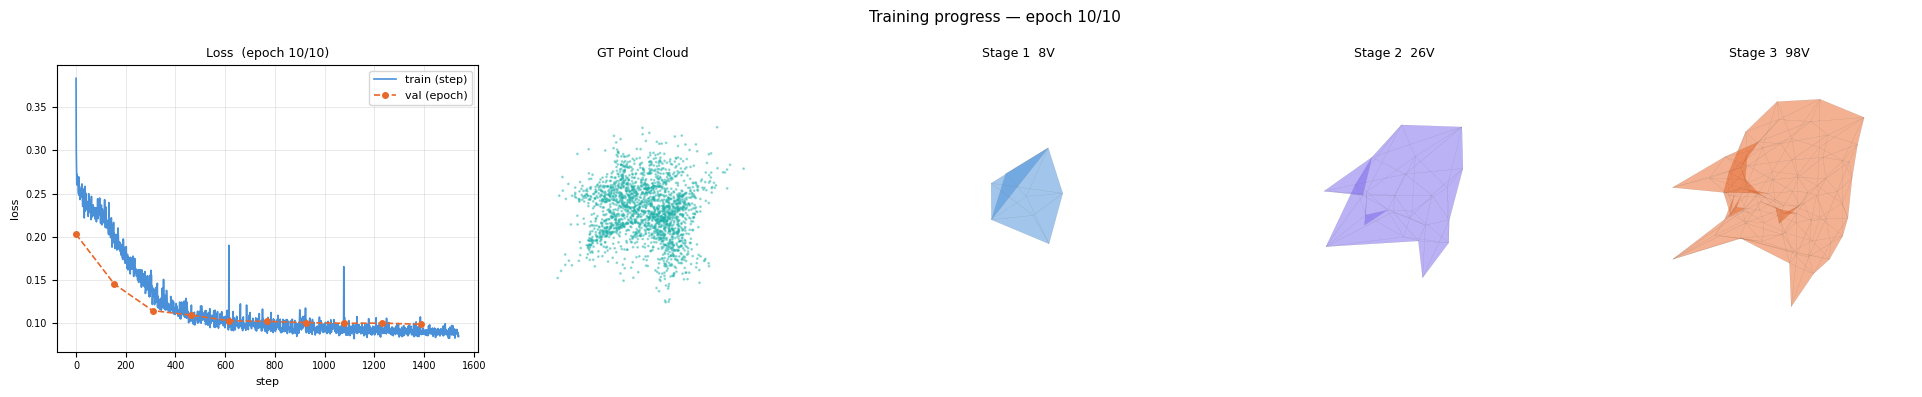

Epochs: 100%|██████████| 10/10 [1:33:25<00:00, 560.58s/epoch, time=561.7s, train=0.0897, val=0.0985]


In [13]:
from torch.utils.data import DataLoader

batch_size = 16
num_workers = 0
train_ds = Pix3DDataset(PIX3D_ROOT, "train", categories=["chair"])
val_ds = Pix3DDataset(PIX3D_ROOT, "val", categories=["chair"])
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

model = Furniture3D(encoder=encoder, hidden_dim=256, n_stages=3, n_gcn_blocks=3).to(DEVICE)
optimizer = torch.optim.AdamW([
    {"params": model.encoder.parameters(),  "lr": 3e-5},
    {"params": [p for n,p in model.named_parameters() if "encoder" not in n], "lr": 3e-4},
], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

history = train(model, train_loader, optimizer, n_epochs=10, val_loader=val_loader)

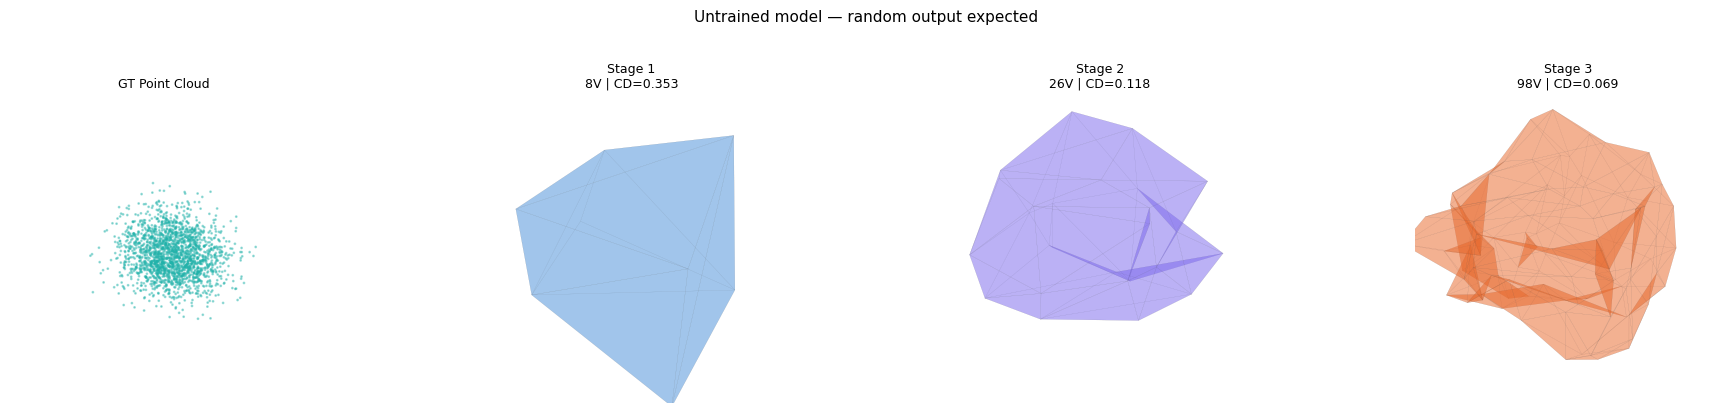

In [14]:
def visualise(pred_verts_list, gt_pts, faces_list, title=""):
    """Plot all 3 deformation stages side by side."""
    n = len(pred_verts_list)
    fig = plt.figure(figsize=(5*n + 4, 4))
    colors = ["#4A90D9","#7B68EE","#E8672A"]

    # GT point cloud
    ax = fig.add_subplot(1, n+1, 1, projection="3d")
    gp = gt_pts[0].cpu().numpy()
    ax.scatter(*gp.T, s=1, c="#20B2AA", alpha=0.4)
    ax.set_title("GT Point Cloud", fontsize=9); ax.set_axis_off()

    # Each deformation stage
    for i, (verts, faces) in enumerate(zip(pred_verts_list, faces_list)):
        ax = fig.add_subplot(1, n+1, i+2, projection="3d")
        pv = verts[0].detach().cpu().numpy()
        ff = faces.cpu().numpy()
        tris = [pv[f] for f in ff]
        poly = Poly3DCollection(tris, alpha=0.3, facecolor=colors[i],
                                edgecolor="#555", linewidth=0.1)
        ax.add_collection3d(poly)
        lim = 0.6
        ax.set_xlim(-lim,lim); ax.set_ylim(-lim,lim); ax.set_zlim(-lim,lim)
        cd = chamfer_distance(verts[:1].to(DEVICE), gt_pts[:1].to(DEVICE))
        ax.set_title(f"Stage {i+1}\n{pv.shape[0]}V | CD={cd.item():.3f}", fontsize=9)
        ax.set_axis_off()

    if title: plt.suptitle(title, y=1.02, fontsize=11)
    plt.tight_layout()
    plt.show()


# Demo with untrained model
fake_gt = torch.randn(1, 2048, 3, device=DEVICE) * 0.4
with torch.no_grad():
    demo_out = smoke_model(
        torch.randn(1,3,224,224,device=DEVICE),
        torch.eye(3,device=DEVICE).unsqueeze(0),
        torch.tensor([[0.,0.,2.]],device=DEVICE),
        torch.tensor([0.85],device=DEVICE)
    )

visualise(demo_out["vertices"], fake_gt, demo_out["faces"], title="Untrained model — random output expected")

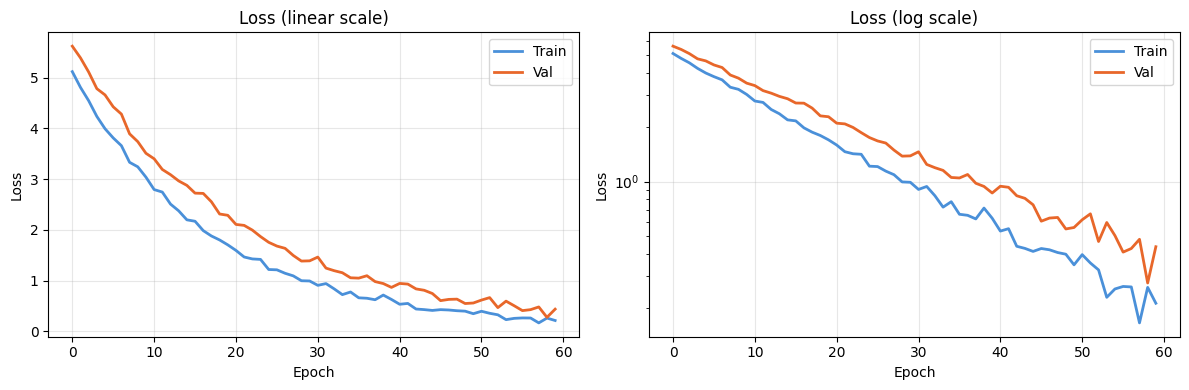

In [15]:
def plot_history(history):
    has_val = bool(history.get("val"))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, yscale in zip(axes, ["linear", "log"]):
        ax.plot(history["train"], label="Train", c="#4A90D9", lw=2)
        if has_val: ax.plot(history["val"], label="Val", c="#E8672A", lw=2)
        ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
        ax.set_yscale(yscale)
        ax.set_title(f"Loss ({yscale} scale)")
        ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# Simulated history for demo
demo_hist = {
    "train": [5.0*np.exp(-0.06*e) + 0.1 + 0.04*np.random.randn() for e in range(60)],
    "val":   [5.5*np.exp(-0.05*e) + 0.12+ 0.06*np.random.randn() for e in range(60)],
}
plot_history(demo_hist)

In [17]:
def save_ckpt(model, optimizer, epoch, path, val_cd=None):
    torch.save({
        "epoch": epoch, 
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "val_cd": val_cd
    }, path)
    print(f"Saved → {path}")


def load_ckpt(model, path, optimizer=None, device=None):
    ckpt = torch.load(path, map_location=device or "cpu")
    model.load_state_dict(ckpt["model"])
    if optimizer: optimizer.load_state_dict(ckpt["optimizer"])
    print(f"Loaded epoch={ckpt['epoch']} val_cd={ckpt.get('val_cd')}")
    return ckpt


save_ckpt(smoke_model, smoke_opt, epoch=0, path="./furniture3d_smoke.pth")
# load_ckpt(smoke_model, "/tmp/furniture3d_smoke.pth", device=DEVICE)

Saved → ./furniture3d_smoke.pth
